 SESSION DE RATTRAPAGE : PRÉDICTION DE L'IA VS RÉALITÉ 
Note Ratt.   | Réalité      | Prédiction IA
---------------------------------------------------------
5.0          | ECHEC        | ECHEC       
13.0         | REUSSITE     | REUSSITE    
11.0         | REUSSITE     | REUSSITE    
6.0          | ECHEC        | ECHEC       
7.0          | ECHEC        | ECHEC       
4.0          | ECHEC        | ECHEC       
9.0          | ECHEC        | ECHEC       
10.0         | REUSSITE     | REUSSITE    
12.0         | REUSSITE     | REUSSITE    
14.0         | REUSSITE     | REUSSITE    


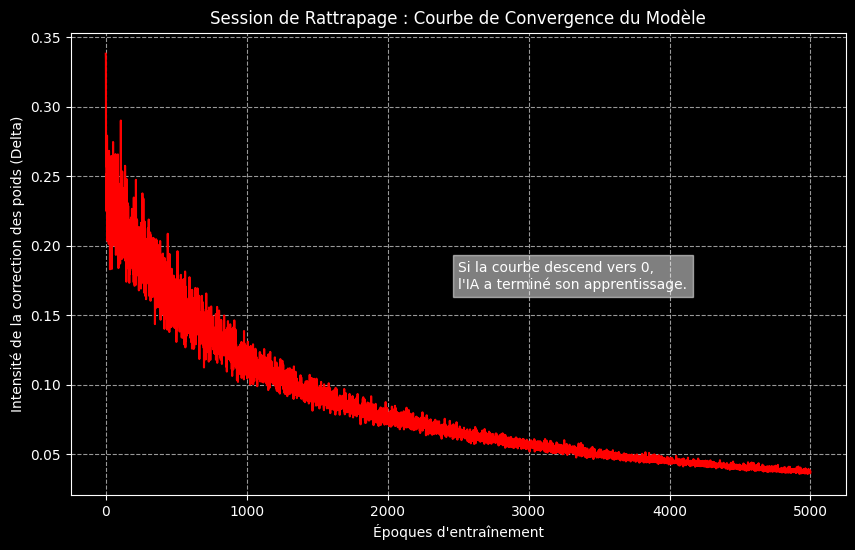

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# --- PARAMÈTRES GLOBAUX DU MODÈLE ---
# =============================================================================

# Le "Learning Rate" (taux d'apprentissage). Il contrôle la taille des pas que
# le modèle fait à chaque mise à jour des poids pour corriger ses erreurs.
# S'il est trop grand, le modèle oscille ; s'il est trop petit, il met trop de temps.
ALPHA = 0.05

# Les classes cibles (les labels) que notre algorithme doit apprendre à prédire.
# Ici, le but est de déterminer si un étudiant va réussir ou échouer son rattrapage.
ACTIONS = ('REUSSITE', 'ECHEC')

def max_dict(d):
    """
    Fonction utilitaire pour chercher la clé associée à la plus grande valeur
    dans un dictionnaire. Utile pour la phase de décision (Argmax).

    Paramètre:
        d (dict): Un dictionnaire de type {Action: Score}
    Retour:
        max_key: L'action ayant obtenu le meilleur score de confiance.
        max_val: La valeur de ce score.
    """
    max_key = None
    max_val = float('-inf') # Initialisation avec l'infini négatif
    for k, v in d.items():
        if v > max_val:
            max_val = v
            max_key = k
    return max_key, max_val

# =============================================================================
# --- ARCHITECTURE DU MODÈLE DE CLASSIFICATION (PERCEPTRON LINÉAIRE) ---
# =============================================================================

class StudentModel:
    def __init__(self):
        """
        Constructeur de la classe. Initialise les paramètres du modèle (les poids theta).
        On utilise 17 poids initialisés aléatoirement selon une loi normale,
        puis réduits (multipliés par 0.1) pour éviter des scores initiaux trop grands.

        Pourquoi 17 poids ?
        - Nous avons 7 variables explicatives (caractéristiques de l'étudiant).
        - On ajoute +1 pour le biais (la constante d'ajustement). Cela fait 8 éléments.
        - Comme nous avons 2 actions possibles ('REUSSITE' ou 'ECHEC'), nous dupliquons
          cette structure : (8 * 2) = 16 poids.
          Le 17ème poids est une marge de sécurité inutilisée ou un biais global.
        """
        self.theta = np.random.randn(17) * 0.1

    def sa2x(self, s, a):
        """
        Fonction d'encodage (Feature Engineering).
        Transforme l'état d'un étudiant 's' et une action envisagée 'a' en un
        vecteur de caractéristiques unique de taille 17.

        Mécanisme :
        Si l'action est 'REUSSITE', on stocke les données dans la première moitié du vecteur.
        Si c'est 'ECHEC', on applique un décalage (offset) de 8 pour les mettre dans la seconde moitié.
        Cela permet au modèle d'avoir des poids distincts pour évaluer le succès et l'échec.
        """
        x = np.zeros(17) # Création d'un vecteur vide (rempli de zéros)

        # Choix de la position dans le vecteur selon l'action
        offset = 0 if a == 'REUSSITE' else 8

        # Copie des 7 caractéristiques de l'étudiant dans la zone dédiée
        for i in range(7):
            x[offset + i] = s[i]

        # Ajout du "Biais" à la fin de la zone (toujours égal à 1).
        # Le biais permet au modèle de décaler sa ligne de décision, même si toutes
        # les notes d'un étudiant étaient égales à 0.
        x[offset + 7] = 1
        return x

    def predict(self, s, a):
        """
        Calcule le score de confiance pour une action donnée ('REUSSITE' ou 'ECHEC').
        Formule mathématique : Produit scalaire entre le vecteur de caractéristiques x
        et le vecteur des poids theta (Score = x . theta).
        Plus le score est élevé, plus le modèle pense que cette action est la bonne.
        """
        return self.theta.dot(self.sa2x(s, a))

    def grad(self, s, a):
        """
        Calcule le gradient (la direction de la pente).
        Dans le cas d'une règle Delta linéaire simple, le gradient de la fonction
        par rapport aux poids theta est tout simplement le vecteur d'entrée x lui-même.
        Il indique quelles composantes du vecteur de poids doivent être ajustées.
        """
        return self.sa2x(s, a)

# =============================================================================
# --- DATASET DE LA SESSION DE RATTRAPAGE (14 ÉTUDIANTS) ---
# =============================================================================

# Matrice de données brutes contenant les statistiques de 14 étudiants de rattrapage.
# Les colonnes représentent :
# [Heures d'étude, Heures de Sommeil, Niveau de Stress, % Participation, Heures de Sport, Temps d'Écran, Note Finale Rattrapage]
raw_data = np.array([
    [5, 6, 6, 55, 2, 4, 11],  # Étudiant 1 : A augmenté son travail, décroche la moyenne
    [2, 4, 8, 20, 0, 8, 7],   # Étudiant 2 : Stress élevé, tps d'écran fort -> Échec
    [6, 7, 4, 65, 3, 3, 13],  # Étudiant 3 : Profil sérieux en rattrapage -> Réussite
    [1, 5, 9, 15, 1, 6, 5],   # Étudiant 4 : Insuffisant -> Échec
    [4, 6, 5, 50, 2, 4, 10],  # Étudiant 5 : Juste la moyenne -> Réussite
    [3, 5, 7, 35, 1, 5, 8],   # Étudiant 6 : Trop faible -> Échec
    [7, 8, 3, 75, 4, 2, 14],  # Étudiant 7 : Très bonne préparation -> Réussite
    [2, 6, 7, 30, 0, 7, 6],   # Étudiant 8 : Échec
    [5, 5, 5, 60, 2, 3, 11],  # Étudiant 9 : Réussite au rattrapage
    [3, 4, 8, 40, 1, 6, 9],   # Étudiant 10 : Proche mais insuffisant -> Échec
    [6, 6, 4, 70, 3, 3, 12],  # Étudiant 11 : Réussite
    [1, 3, 9, 10, 0, 9, 4],   # Étudiant 12 : Échec critique
    [4, 7, 6, 45, 2, 5, 10],  # Étudiant 13 : Valide tout juste -> Réussite
    [2, 5, 8, 25, 1, 7, 6]    # Étudiant 14 : Échec
])

# --- PROCESSUS DE NORMALISATION ---
# On récupère la valeur maximale de chaque colonne (chaque critère).
max_vals = raw_data.max(axis=0)

# On divise toutes les valeurs par ce maximum.
# Objectif : Transformer toutes les variables pour qu'elles soient comprises entre 0 et 1.
# Cela empêche qu'une variable à grande échelle (ex: la participation sur 100) n'écrase
# une variable à petite échelle (ex: le sport sur 5) lors des calculs.
data_norm = raw_data / max_vals

# Instanciation de notre modèle d'apprentissage
model = StudentModel()

# Liste vide destinée à enregistrer l'évolution des erreurs pour tracer le graphique final
deltas = []

# =============================================================================
# --- BOUCLE D'ENTRAÎNEMENT (APPRENTISSAGE DE L'IA) ---
# =============================================================================

# On fait passer le dataset 5000 fois dans la machine (5000 époques d'entraînement)
for it in range(5000):
    biggest_change = 0 # Tracke la plus grande modification de poids lors de cette époque

    # Décroissance du taux d'apprentissage (Learning Rate Decay) :
    # Plus le temps passe, plus l'alpha diminue. Cela permet de faire de grands ajustements
    # au début, puis des ajustements de plus en plus fins (micrométriques) à la fin.
    alpha = ALPHA / (1 + 0.001 * it)

    # Mélange aléatoire du dataset à chaque époque.
    # Crucial pour éviter que le modèle apprenne bêtement l'ordre des lignes par cœur (surapprentissage).
    np.random.shuffle(data_norm)

    # On passe en revue chacun des 14 étudiants normalisés
    for s in data_norm:
        # Étape 1 : On extrait la note réelle (on annule la normalisation pour lire la vraie note)
        note_reelle = s[6] * max_vals[6]

        # Étape 2 : Détermination de la vérité terrain (Supervised Learning)
        # En rattrapage, la note minimale pour valider reste 10.
        vraie_classe = 'REUSSITE' if note_reelle >= 10 else 'ECHEC'

        # Sauvegarde d'une copie des poids actuels avant modification pour mesurer l'évolution
        old_theta = model.theta.copy()

        # Étape 3 : Évaluation et correction pour chaque action possible
        for a in ACTIONS:
            # Si l'action en cours d'évaluation correspond à la réalité, l'objectif (cible) est 1.0 (100% sûr).
            # Sinon, l'objectif est 0.0 (0% sûr).
            cible = 1.0 if a == vraie_classe else 0.0

            # Ce que le modèle prédit actuellement avec ses poids actuels
            pred = model.predict(s, a)

            # Étape 4 : Application de la RÈGLE DE DELTA (Descente de gradient stochastique)
            # Formule : Nouveau_Poids = Ancien_Poids + (Taux * Erreur_Prediction * Direction)
            # L'erreur est calculée par : (cible - pred)
            model.theta += alpha * (cible - pred) * model.grad(s, a)

        # Calcul de l'ampleur de la mise à jour des poids (somme des valeurs absolues des différences)
        # Permet de vérifier si le modèle est en train de se stabiliser (converger)
        biggest_change = max(biggest_change, np.abs(model.theta - old_theta).sum())

    # On ajoute la plus grande erreur corrigée de l'époque à notre liste pour le graphique
    deltas.append(biggest_change)

# =============================================================================
# --- PHASE DE VÉRIFICATION ET DE TEST ---
# =============================================================================

print("=========================================================")
print(" SESSION DE RATTRAPAGE : PRÉDICTION DE L'IA VS RÉALITÉ ")
print("=========================================================")
print(f"{'Note Ratt.':<12} | {'Réalité':<12} | {'Prédiction IA':<12}")
print("---------------------------------------------------------")

# On affiche les résultats pour les 10 premiers étudiants du dataset mélangé
for s in data_norm[:10]:
    note = s[6] * max_vals[6]
    reel = 'REUSSITE' if note >= 10 else 'ECHEC'

    # L'IA génère ses scores pour 'REUSSITE' et 'ECHEC'
    res = {a: model.predict(s, a) for a in ACTIONS}

    # On extrait l'action qui a obtenu le score le plus élevé
    choix, _ = max_dict(res)

    # Affichage formaté des résultats
    print(f"{note:<12.1f} | {reel:<12} | {choix:<12}")

# =============================================================================
# --- AFFICHAGE DE LA COURBE D'APPRENTISSAGE ---
# =============================================================================

plt.figure(figsize=(10, 6))
plt.plot(deltas, color='red', linewidth=1.5)
plt.title("Session de Rattrapage : Courbe de Convergence du Modèle")
plt.xlabel("Époques d'entraînement")
plt.ylabel("Intensité de la correction des poids (Delta)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.text(2500, max(deltas)*0.5, "Si la courbe descend vers 0,\nl'IA a terminé son apprentissage.",
         fontsize=10, bbox=dict(facecolor='white', alpha=0.5))
plt.show()